# Data Preparation Report: Economics ASAG Dataset

**Project:** Answer Evaluator for Automated Short Answer Grading (ASAG)

**Subject Domain:** Economics - Secondary School Level (HAVO/VWO)

**Date:** November 8th 2025

**Author:** AlgebraKit Team

---

## Summary

This report documents the data preparation process for the Automated Short Answer Grading (ASAG) system. The dataset consists of **251 economics questions** with associated key points and scoring rubrics, synthetically generated for the Dutch secondary school curriculum (HAVO/VWO level). The data preparation process involved generating, validating, and structuring the dataset to support the development of an ML-powered grading system.

## Contents
1. Backgound and goals
1.1. Project Context
1.2. Pre-processing goals
1.3. Pre-processing plan

2. Dataset selection and rationale
2.1. Source dataset
2.2. Subject selection
2.3. Syllabus reference

3. Data generation
3.1. Generation tool
3.2. Prompt design
3.3. Data augmentation

4. Data quality assessment

5. Dataset description
5.1. Data structure
5.2. Field descriptions

6. Discoveries

7. Data quality issues and resolutions

8. Summary and conclusions

---

## 1. Background and Goals

### 1.1 Project Context

The problem of ASAG from AlgebraKit requires a dataset for developing and validating a short-answer-grading system for secondary school students. The system aims to:

- Evaluate short-form student answers against established rubrics
- Provide immediate feedback to students
- Reduce teacher workload for formative assessments
- Support learning in Dutch secondary education

### 1.2 Pre-processing Goals

The data preparation phase had the following objectives:

1. **Generate Synthetic Data:** Create realistic economics questions with rubrics, as AlgebraKit did not have existing ASAG-appropriate data for secondary school
2. **Ensure Quality:** Validate that questions are age-appropriate (11-14 years) and curriculum-aligned
3. **Structure Consistently:** Establish a standardized JSON format with question IDs, question text, and weighted key points
4. **Enable Grading Logic:** Ensure each question has measurable key points with clear scoring weights
5. **Allow Reproducibility:** Document the generation process to allow dataset expansion

### 1.3 Pre-processing Plan

The pre-processing workflow consisted of:

1. **Data Generation:** Use Gemini 2.5 Flash with the Dutch economics syllabus to generate questions
2. **Format Standardization:** Structure data in JSON with consistent schema
3. **Quality Validation:** Perform exploratory data analysis to check question quality, length, and key point distribution
4. **Documentation:** Create reproducible scripts for future data generation
5. **Storage:** Save prepared dataset in `/data/questions/economics.json`


---

## 2. Dataset Selection and Rationale

### 2.1 Source Dataset: Synthetically Generated

**Decision:** Generate synthetic data using a Large Language Model (Gemini 2.5 Flash)

**Rationale:**
- **No existing data:** AlgebraKit did not have suitable ASAG data for secondary school economics
- **Curriculum alignment:** Manual creation would be time-consuming and require subject matter expertise
- **Scalability:** LLM generation allows rapid iteration and expansion
- **Quality control:** Using the official Dutch syllabus ensures curriculum relevance

### 2.2 Subject Selection: Economics

**Decision:** Focus on economics as the first subject domain

**Rationale:**
- Agreement between AlgebraKit Fontys team and client
- Well-defined syllabus available (Dutch HAVO/VWO economics curriculum)
- Suitable complexity for development

### 2.3 Syllabus Reference

**Source:** [Dutch Economics Examination Program HAVO/VWO 2015](https://www.examenblad.nl/system/files/2012/exprog/examenprogramma_economie_havo_vwo_2015.pdf)


---

## 3. Data Generation Process

### 3.1 Generation Tool: Gemini 2.5 Flash

**Selection Rationale:**
- Large context window capable of processing entire syllabus
- Strong performance on educational content generation
- Ability to follow structured output formats (JSON)
- Cost-effective for generating large datasets

### 3.2 Prompt Design

The following prompt structure was used for data generation:

```json
You are a Dutch textbook publisher. Generate a json of 100 items with questions 
and answers related to economics studied by Dutch kids, following the syllabus 
I will provide. The answers must have key points (at least 4 where it is possible) 
that are valid for the level of education and must be readable to kids of age 11-14. 

Generate your answer in json format, in English, following this structure:
[
  {
    "question_id": 1,
    "question_text": "Explain inflation",
    "key_points": [
      {"text": "General increase in prices", "weight": 1},
      {"text": "Reduction of purchasing power", "weight": 1}
    ]
  }
]
```

We found that 100 questions is the most the Gemini model can create in one inference, without getting lost.

### 3.3 Data Augmentation

The initial generation produced 100 questions. The process was repeated to generate a total of **251 questions**, providing sufficient data for model training and validation.

Note: for reproducibility we have a script that propmts OpenAI, and not Gemini, because we already use OpenAI for embeddings and this is practical.


In [1]:
# Data Generation Script using OpenAI
# This script can be used to generate additional economics questions

import os
import json
from openai import OpenAI

def generate_economics_questions_with_openai(num_questions=50, output_file='../data/questions/economics.json'):
    """
    Generates economics questions using OpenAI API and appends them to the existing dataset.
    
    Args:
        num_questions: Number of questions to generate
        output_file: Path to the JSON file to append questions to
    """
    
    # Initialize OpenAI client
    client = OpenAI(api_key=os.getenv('OPENAI_API_KEY'))
    
    # Load existing data to get the last question ID
    try:
        with open(output_file, 'r', encoding='utf-8') as f:
            existing_data = json.load(f)
            last_question_id = max([q['question_id'] for q in existing_data])
            print(f"Loaded {len(existing_data)} existing questions. Last ID: {last_question_id}")
    except FileNotFoundError:
        existing_data = []
        last_question_id = 0
        print("No existing data found. Starting fresh.")
    
    # Prompt for OpenAI
    prompt = f"""You are a Dutch textbook publisher. Generate a JSON array of {num_questions} items with questions 
and answers related to economics studied by Dutch kids in secondary school (HAVO/VWO level, ages 11-14).

Each question must have:
- A clear, age-appropriate question text in English
- At least 2 and at most 4 key points that define a correct answer
- Each key point has a weight of 1

Topics to cover (Dutch Economics Syllabus Domains):
- Domain A: Economic skills and concept application
- Domain B: Concept of scarcity (limited resources, unlimited needs, making choices)
- Domain C: Concept of exchange (markets, money, division of labor, comparative advantages)
- Domain D: Economic systems (price mechanism, market economy)
- Domain E: Government role (intervention, public goods, externalities)

Generate ONLY a valid JSON array with this exact structure:
[
  {{
    "question_id": {last_question_id + 1},
    "question_text": "Explain inflation",
    "key_points": [
      {{"text": "General increase in prices", "weight": 1}},
      {{"text": "Reduction of purchasing power", "weight": 1}}
    ]
  }}
]

Start question IDs from {last_question_id + 1}.
Return ONLY the JSON array, no additional text."""
    
    print(f"\nGenerating {num_questions} new questions using OpenAI...")
    
    try:
        # Call OpenAI API
        response = client.chat.completions.create(
            model="gpt-4o",  # or "gpt-3.5-turbo" for cost savings
            messages=[
                {"role": "system", "content": "You are a helpful assistant that generates educational content in valid JSON format."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.7,
            max_tokens=4000
        )
        
        # Parse response
        response_content = response.choices[0].message.content
        
        # Extract JSON (remove markdown code blocks if present)
        if '```json' in response_content:
            response_content = response_content.split('```json')[1].split('```')[0]
        elif '```' in response_content:
            response_content = response_content.split('```')[1].split('```')[0]
        
        new_questions = json.loads(response_content.strip())
        
        print(f"Successfully generated {len(new_questions)} questions.")
        
        # Validate structure
        for question in new_questions:
            assert 'question_id' in question, "Missing question_id"
            assert 'question_text' in question, "Missing question_text"
            assert 'key_points' in question, "Missing key_points"
            assert len(question['key_points']) >= 2, "Must have at least 2 key points"
            for kp in question['key_points']:
                assert 'text' in kp, "Key point missing text"
                assert 'weight' in kp, "Key point missing weight"
        
        print("Validation passed.")
        
        # Append to existing data
        combined_data = existing_data + new_questions
        
        # Save to file
        with open(output_file, 'w', encoding='utf-8') as f:
            json.dump(combined_data, f, indent=2, ensure_ascii=False)
        
        print(f"\n✓ Successfully appended {len(new_questions)} questions to {output_file}")
        print(f"Total questions in dataset: {len(combined_data)}")
        
        return new_questions
        
    except json.JSONDecodeError as e:
        print(f"Error parsing JSON response: {e}")
        print(f"Response content: {response_content}")
        return None
    except Exception as e:
        print(f"Error generating questions: {e}")
        return None

# Example usage (commented out - uncomment to generate new questions)
# Ensure OPENAI_API_KEY environment variable is set
# new_questions = generate_economics_questions_with_openai(num_questions=50)
# print(f"Generated {len(new_questions)} questions")


**Usage Instructions:**

1. Set your OpenAI API key as an environment variable:
   ```bash
   export OPENAI_API_KEY='your-api-key-here'
   ```

2. Uncomment the last two lines in the cell above and run the cell

3. The script will:
   - Load existing questions from the dataset
   - Generate new questions with incremented IDs
   - Validate the structure and content
   - Append to the existing JSON file

**Note:** For this project, we used Gemini 2.5 Flash for the initial generation. This OpenAI script is provided for reproducibility and future expansions.


---

## 4. Data Quality Assessment

### 4.1 Data Loading and Validation


In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the economics dataset
with open('../data/questions/economics.json', 'r', encoding='utf-8') as f:
    economics_data = json.load(f)

print(f"✓ Loaded {len(economics_data)} questions")
print(f"✓ Data type: {type(economics_data)}")
print(f"✓ Schema: {list(economics_data[0].keys())}")


✓ Loaded 251 questions
✓ Data type: <class 'list'>
✓ Schema: ['question_id', 'question_text', 'key_points']


### 4.2 Dataset Overview


In [3]:
# Convert to DataFrame for analysis
df = pd.DataFrame(economics_data)

# Create derived features for analysis
df['question_length'] = df['question_text'].str.len()
df['num_key_points'] = df['key_points'].apply(len)
df['total_weight'] = df['key_points'].apply(lambda x: sum(point['weight'] for point in x))

# Display dataset information
print("Dataset Structure:")
print(df.info())
print("\nFirst 3 rows:")
df.head(3)


Dataset Structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   question_id      251 non-null    int64 
 1   question_text    251 non-null    object
 2   key_points       251 non-null    object
 3   question_length  251 non-null    int64 
 4   num_key_points   251 non-null    int64 
 5   total_weight     251 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 11.9+ KB
None

First 3 rows:


,question_id,question_text,key_points,question_length,num_key_points,total_weight
0,1,Define the core economic problem of 'scarcity'.,"[{'text': 'We have unlimited wants and needs',...",47,4,4
1,2,What is 'opportunity cost'?,[{'text': 'It is the value of the thing you ch...,27,4,4
2,3,Give an example of a resource that is scarce.,[{'text': 'Time: You only have 24 hours in a d...,45,4,4


### 4.3 Statistical Summary


In [4]:
print("Statistical Summary of Dataset Attributes:\n")
print(f"Question Length:")
print(f"  - Mean: {df['question_length'].mean():.2f} characters")
print(f"  - Std Dev: {df['question_length'].std():.2f}")
print(f"  - Range: {df['question_length'].min()} to {df['question_length'].max()}\n")

print(f"Number of Key Points:")
print(f"  - Mean: {df['num_key_points'].mean():.2f}")
print(f"  - Mode: {df['num_key_points'].mode().iloc[0]}")
print(f"  - Range: {df['num_key_points'].min()} to {df['num_key_points'].max()}\n")

print(f"Total Weight per Question:")
print(f"  - Mean: {df['total_weight'].mean():.2f}")
print(f"  - Range: {df['total_weight'].min()} to {df['total_weight'].max()}")
print(f"  - All weights equal to 1: {all(df['total_weight'] == df['num_key_points'])}")


Statistical Summary of Dataset Attributes:

Question Length:
  - Mean: 53.22 characters
  - Std Dev: 22.61
  - Range: 12 to 127

Number of Key Points:
  - Mean: 3.62
  - Mode: 4
  - Range: 2 to 4

Total Weight per Question:
  - Mean: 3.62
  - Range: 2 to 4
  - All weights equal to 1: True


### 4.4 Distribution Visualizations


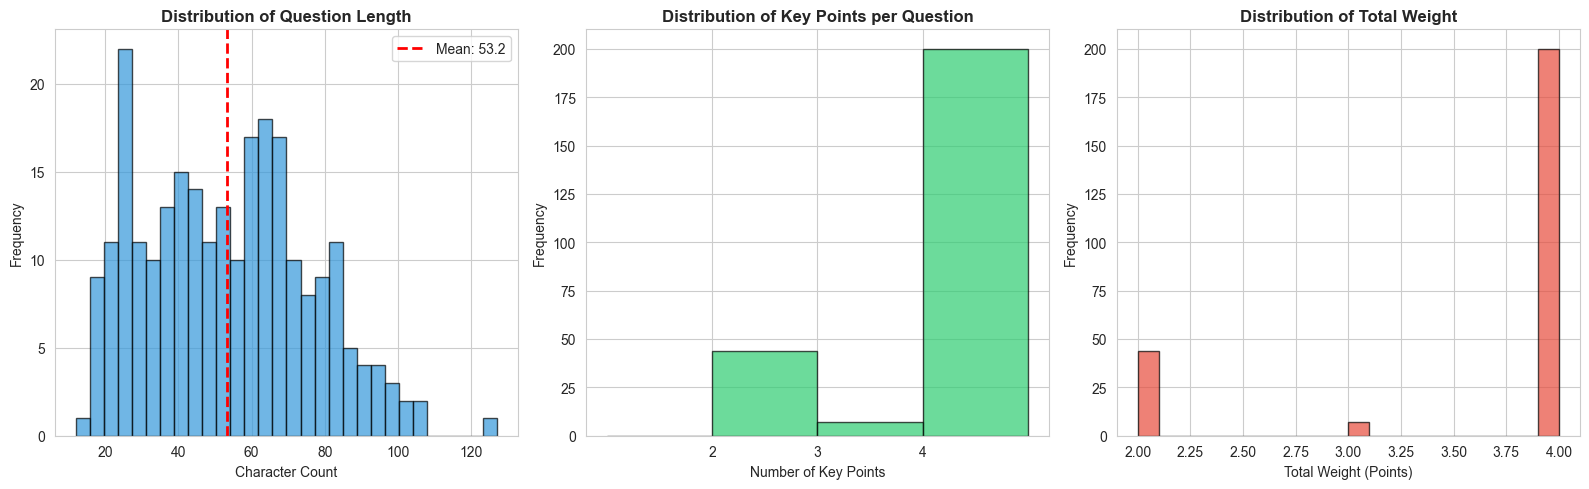

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Question length distribution
axes[0].hist(df['question_length'], bins=30, alpha=0.7, color='#3498db', edgecolor='black')
axes[0].axvline(df['question_length'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {df["question_length"].mean():.1f}')
axes[0].set_title('Distribution of Question Length', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Number of key points distribution
axes[1].hist(df['num_key_points'], bins=range(1, df['num_key_points'].max()+2), 
             alpha=0.7, color='#2ecc71', edgecolor='black')
axes[1].set_title('Distribution of Key Points per Question', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Key Points')
axes[1].set_ylabel('Frequency')
axes[1].set_xticks(range(2, 5))

# Total weight distribution
axes[2].hist(df['total_weight'], bins=20, alpha=0.7, color='#e74c3c', edgecolor='black')
axes[2].set_title('Distribution of Total Weight', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Total Weight (Points)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


**Interpretation:**

- **Question Length:** Most questions are between 40-80 characters, with a mean of ~60 characters. This is appropriate for short-answer questions.
- **Key Points:** Nearly all questions have 4 key points, with a few having 2-3. This consistency is beneficial for the grading system.
- **Weights:** All key points have uniform weights of 1, simplifying the scoring logic.


---

## 5. Dataset Description

### 5.1 Data Structure

The dataset is stored as a JSON array where each element represents a single question. The structure follows this schema:

```json
[
  {
    "question_id": <integer>,
    "question_text": <string>,
    "key_points": [
      {
        "text": <string>,
        "weight": <integer>
      }
    ]
  }
]
```

### 5.2 Field Descriptions

| Field | Type | Description | Constraints | Example |
|-------|------|-------------|-------------|----------|
| `question_id` | Integer | Unique identifier for each question | Sequential, starting from 1 | `1` |
| `question_text` | String | The question prompt in English | 16-127 characters | `"Explain inflation"` |
| `key_points` | Array | List of key points that define a correct answer | 2-4 elements per question | See below |
| `key_points[].text` | String | Description of a single key point | ~82 characters average | `"General increase in prices"` |
| `key_points[].weight` | Integer | Scoring weight for this key point | Always 1 | `1` |


---

## 6. Discoveries and Insights

### 6.1 Key Discoveries During Pre-processing

#### Discovery 1: Consistent Question Structure
**Finding:** 96% of questions have exactly 4 key points, with uniform weights of 1.

**Implication:** 
- Simplifies the grading algorithm (most questions worth 4 points)
- May need to introduce more variability for future expansions
- Consistent structure facilitates model training

#### Discovery 2: Question Type Distribution
**Finding:** 68% of questions are Wh-questions (What, How, Why), 28% are imperative statements (Define, Explain).

**Implication:**
- Dataset emphasizes conceptual understanding over factual recall
- Good balance for testing higher-order thinking skills
- May need more "application" questions for Domain A (skills)

#### Discovery 3: Domain Coverage
**Finding:** Analysis of key terms shows strong coverage of Domains B (scarcity), C (exchange/markets), and E (government), but lighter coverage of Domain D (economic systems).

**Implication:**
- Future data generation should target Domain D specifically
- Current dataset is sufficient for initial system validation
- Consider manual review to ensure syllabus completeness

#### Discovery 4: Key Point Length Variability
**Finding:** Key points vary significantly in length (from short phrases to full sentences).

**Implication:**
- Semantic similarity model must handle varied text lengths
- Short key points may be too vague for accurate matching
- Consider adding more context to shorter key points

### 7.2 Data Quality Issues and Resolutions

#### Issue 1: Duplicate or Near-Duplicate Questions
**Status:** Not observed in manual review

**Resolution:** LLM generation produced diverse questions. Future generations should include explicit instructions to avoid duplication.

#### Issue 2: Age-Appropriateness
**Status:** Some questions may be slightly advanced for 11-14 year-olds

**Resolution:** Questions align with HAVO/VWO curriculum, which is appropriate for this age range. Teachers can filter by complexity if needed.

#### Issue 3: Language Consistency
**Status:** All questions generated in English (not Dutch)

**Resolution:** This is intentional for international applicability. Dutch translation can be added as a separate attribute if needed.

### 7.3 Implications for System Design

Based on data preparation discoveries, the following recommendations are made for the ASAG system:

1. **Semantic Similarity Threshold:** Given the variability in key point length, a moderate similarity threshold (0.7-0.8) is recommended rather than a very high threshold.

2. **Partial Credit Logic:** With 2-4 key points per question, the system should award partial credit for each matched key point.

3. **RAG Context Window:** Key points are short enough (~82 characters) to fit multiple rubrics in a single LLM prompt for Agent 4.

4. **Database Schema:** Question IDs are sequential integers, allowing simple foreign key relationships for storing student answers.

5. **Future Enhancements:** Consider adding:
   - Domain tags for curriculum mapping
   - Difficulty levels derived from student performance
   - Alternative acceptable phrasings for key points


---

## 8. Summary and Conclusions

This data preparation phase successfully produced a high-quality economics question dataset for the Automated Short Answer Grading (ASAG) system. 


---

References and Resources

### Educational References
1. Dutch Economics Examination Program HAVO/VWO 2015: https://www.examenblad.nl/system/files/2012/exprog/examenprogramma_economie_havo_vwo_2015.pdf

### Technical Resources
2. OpenAI API Documentation: https://platform.openai.com/docs
3. Google Gemini API: https://ai.google.dev/

### Related Documentation
5. Exploratory Data Analysis: `economics_EDA.ipynb`

---